**https://www.kaggle.com/datasets/ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning**

The Dirty Retail Store Sales dataset contains 12,575 rows of synthetic data representing sales transactions from a retail store. The dataset includes eight product categories with 25 items per category, each having static prices. It is designed to simulate real-world sales data, including intentional "dirtiness" such as missing or inconsistent values. This dataset is suitable for practicing data cleaning, exploratory data analysis (EDA), and feature engineering.

In [1]:
import kagglehub
import shutil
import os
# Download latest version
download_path = kagglehub.dataset_download("ahmedmohamed2003/retail-store-sales-dirty-for-data-cleaning")

print("Path to dataset files:", download_path)
target_path = "../data/raw"


# 3. Copy toàn bộ dữ liệu sang thư mục mới
if os.path.exists(target_path):
    shutil.rmtree(target_path) # Xóa nếu thư mục đã tồn tại để tránh lỗi
shutil.copytree(download_path, target_path)

print("Dữ liệu đã được lưu tại:", os.path.abspath(target_path))

C:\Users\Win 11\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Win 11\.cache\kagglehub\datasets\ahmedmohamed2003\retail-store-sales-dirty-for-data-cleaning\versions\1
Dữ liệu đã được lưu tại: C:\Users\Win 11\Documents\ML\ML_proj_26\lab2\data\raw


# Bước 1. Tổng Quan Dữ Liệu & Kiểu Dữ Liệu (Data Overview & Data Types)

Trong bước này, chúng ta sẽ nạp dữ liệu từ thư mục raw, kiểm tra kích thước dữ liệu, hiển thị một số bản ghi đầu/cuối và kiểm tra kiểu dữ liệu của các cột.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Thiết lập hiển thị cho đồ thị và pandas
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Đường dẫn tới dữ liệu thô
csv_path = '../data/raw/retail_store_sales.csv'
df = pd.read_csv(csv_path)

# 1. Kích thước dữ liệu
print(f'Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột')
print('-'*50)

# 2. Thông tin kiểu dữ liệu
print(df.info())

Kích thước dữ liệu: 12575 dòng, 11 cột
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.9+ MB
None


### Xem trước một số dòng dữ liệu mẫu (head, tail, sample)

In [3]:
# 5 dòng đầu tiên
print('--- 5 Dòng Đầu ---')
display(df.head())

# 5 dòng cuối cùng
print('--- 5 Dòng Cuối ---')
display(df.tail())

# 5 dòng ngẫu nhiên
print('--- 5 Dòng Ngẫu Nhiên ---')
display(df.sample(5))

--- 5 Dòng Đầu ---


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


--- 5 Dòng Cuối ---


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


--- 5 Dòng Ngẫu Nhiên ---


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12382,TXN_5035840,CUST_24,Electric household essentials,Item_11_EHE,20.0,7.0,140.0,Digital Wallet,In-store,2022-05-03,True
8115,TXN_9359126,CUST_08,Beverages,Item_16_BEV,27.5,6.0,165.0,Credit Card,In-store,2023-02-25,NaN
8906,TXN_9424217,CUST_17,Furniture,Item_6_FUR,12.5,3.0,37.5,Cash,Online,2022-12-21,True
5218,TXN_4311728,CUST_20,Food,Item_12_FOOD,21.5,6.0,129.0,Cash,In-store,2023-04-20,True
11119,TXN_2838184,CUST_21,Computers and electric accessories,Item_5_CEA,11.0,8.0,88.0,Credit Card,Online,2022-03-15,True


# Bước 2. Thống Kê Tổng Hợp (Summary Statistics)

Chúng ta sẽ xem xét các chỉ số mô tả toán học của cả biến số (Numerical) và biến phân loại (Categorical).

In [4]:
# Thống kê tổng hợp cho thuộc tính số
print('--- Thống kê các cột số ---')
display(df.describe())

# Thống kê tổng hợp cho thuộc tính phân loại
print('--- Thống kê các cột chữ/danh mục ---')
display(df.describe(include=['object', 'str', 'O']))

--- Thống kê các cột số ---


,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


--- Thống kê các cột chữ/danh mục ---


,Transaction ID,Customer ID,Category,Item,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,12575,12575,12575,8376
unique,12575,25,8,200,3,2,1114,2
top,TXN_6867343,CUST_05,Furniture,Item_2_BEV,Cash,Online,2022-05-30,True
freq,1,544,1591,126,4310,6354,26,4219


### Tần suất của từng thuộc tính phân loại chính

In [5]:
for col in ['Category', 'Payment Method', 'Location', 'Discount Applied']:
    print(f'=== Tần suất cột: {col} ===')
    val_counts = df[col].value_counts(dropna=False)
    pcts = df[col].value_counts(dropna=False, normalize=True) * 100
    summary = pd.DataFrame({'Số lượng': val_counts, 'Tỷ lệ (%)': pcts})
    display(summary)
    print('\n')

=== Tần suất cột: Category ===


,Số lượng,Tỷ lệ (%)
Category,,
Furniture,1591,12.652087
Electric household essentials,1591,12.652087
Food,1588,12.628231
Milk Products,1584,12.596421
Butchers,1568,12.469185
Beverages,1567,12.461233
Computers and electric accessories,1558,12.389662
Patisserie,1528,12.151093




=== Tần suất cột: Payment Method ===


,Số lượng,Tỷ lệ (%)
Payment Method,,
Cash,4310,34.274354
Digital Wallet,4144,32.954274
Credit Card,4121,32.771372




=== Tần suất cột: Location ===


,Số lượng,Tỷ lệ (%)
Location,,
Online,6354,50.528827
In-store,6221,49.471173




=== Tần suất cột: Discount Applied ===


,Số lượng,Tỷ lệ (%)
Discount Applied,,
True,4219,33.550696
NaN,4199,33.391650
False,4157,33.057654


# Bước 3. Phân Tích Đơn Biến & Phân Phối (Univariate Analysis & Distributions)

Vẽ biểu đồ phân phối cho từng biến đơn lẻ để hiểu dạng phân phối của dữ liệu.

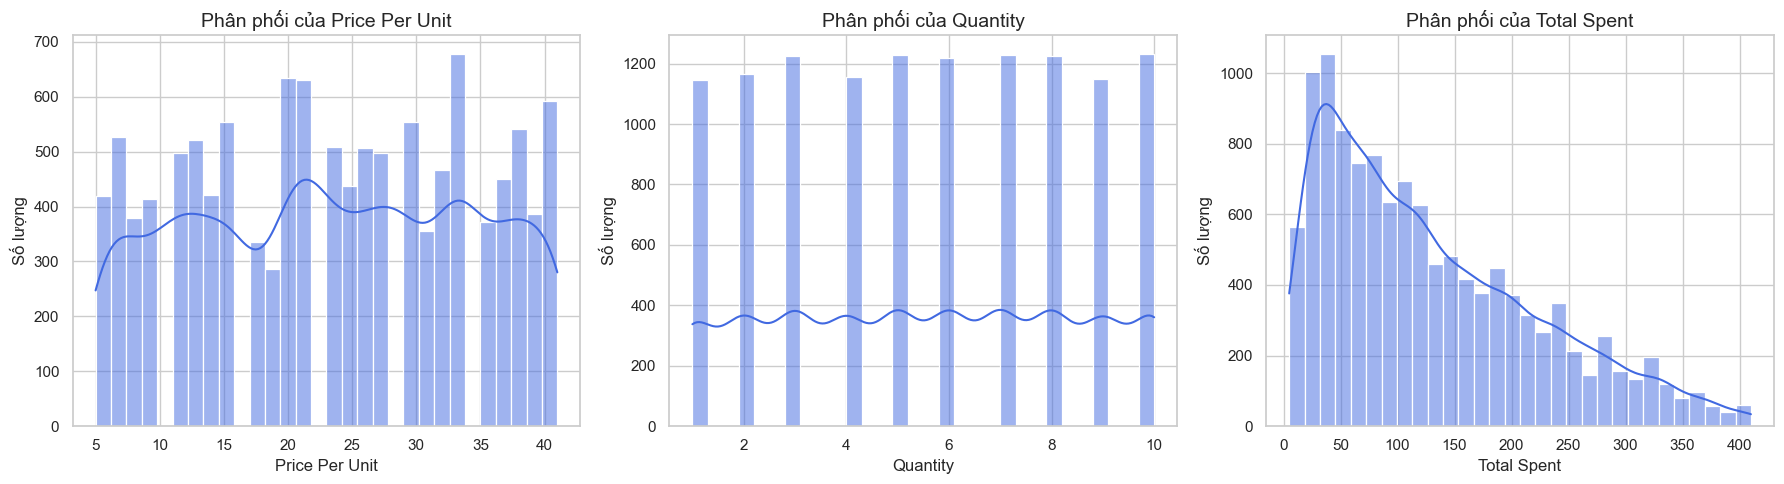

In [6]:
# Vẽ phân phối các cột số
num_cols = ['Price Per Unit', 'Quantity', 'Total Spent']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='royalblue', bins=30)
    axes[i].set_title(f'Phân phối của {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

### Phân phối của các thuộc tính phân loại

C:\Users\Win 11\AppData\Local\Temp\ipykernel_5996\2888913154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=temp_series, ax=axes[i], palette='viridis', order=temp_series.value_counts().index)
C:\Users\Win 11\AppData\Local\Temp\ipykernel_5996\2888913154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=temp_series, ax=axes[i], palette='viridis', order=temp_series.value_counts().index)


C:\Users\Win 11\AppData\Local\Temp\ipykernel_5996\2888913154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=temp_series, ax=axes[i], palette='viridis', order=temp_series.value_counts().index)
C:\Users\Win 11\AppData\Local\Temp\ipykernel_5996\2888913154.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=temp_series, ax=axes[i], palette='viridis', order=temp_series.value_counts().index)


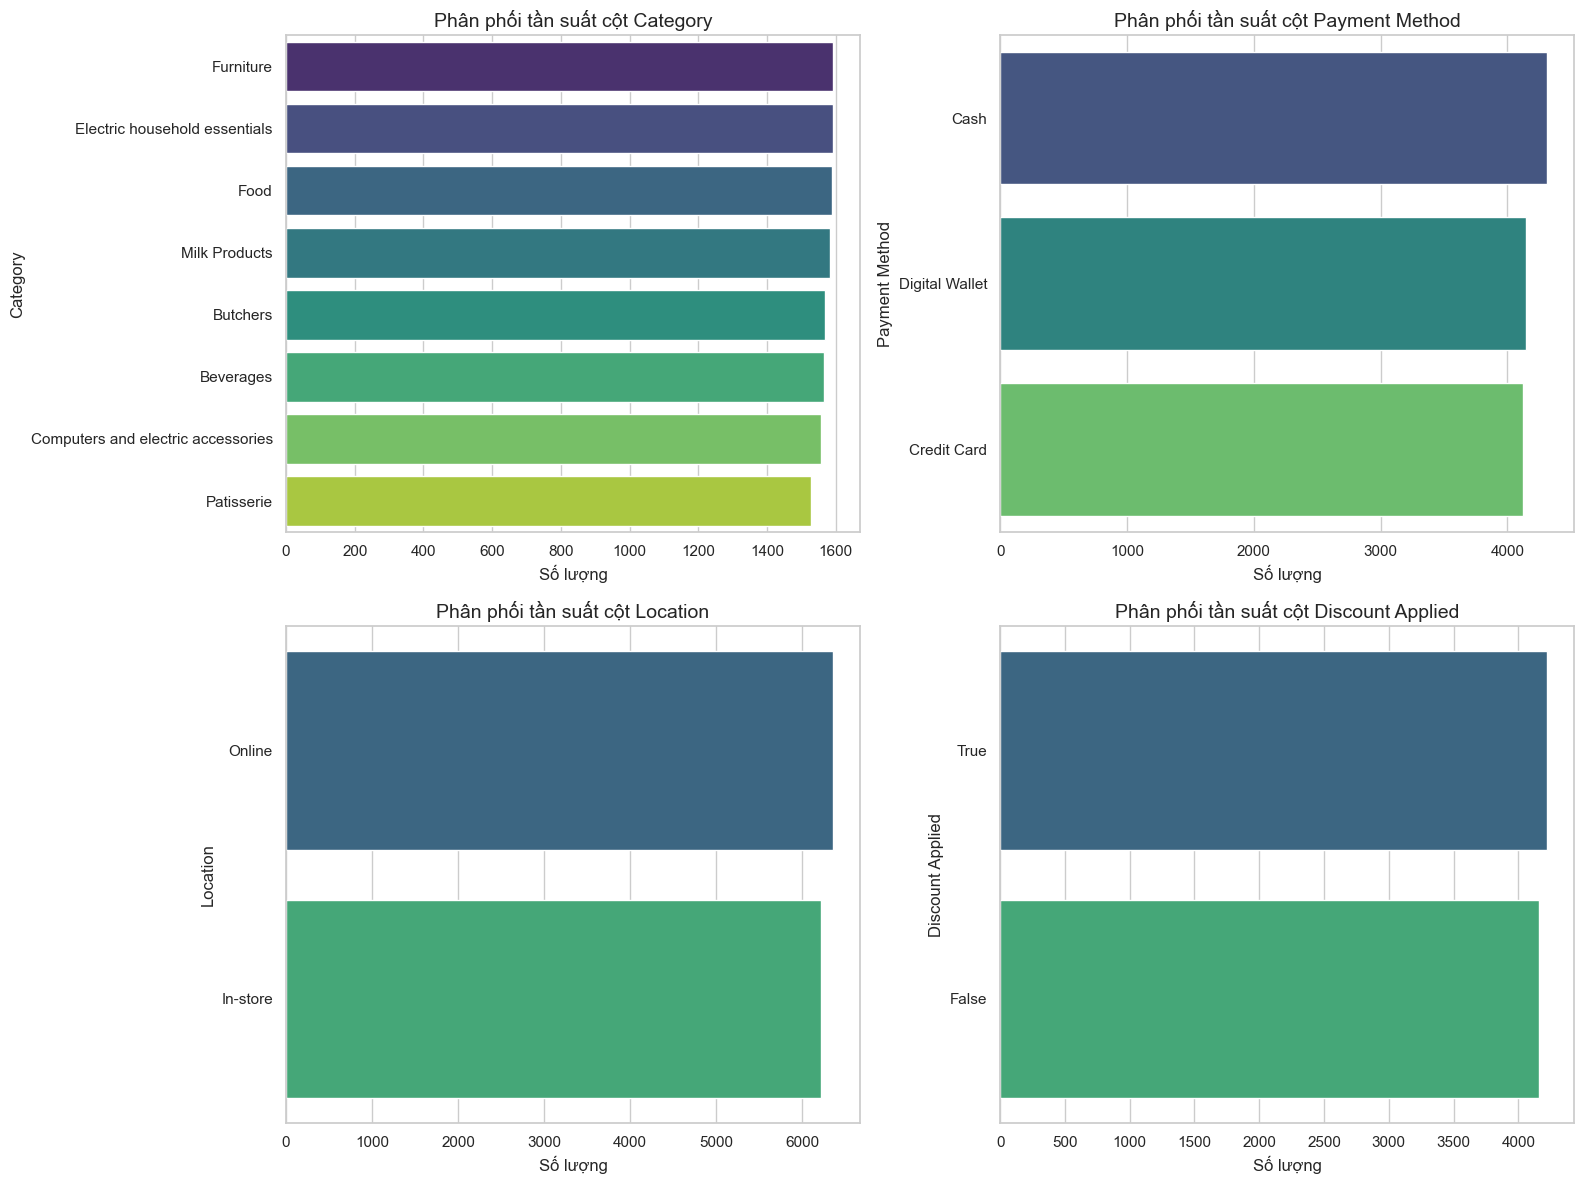

In [7]:
cat_cols = ['Category', 'Payment Method', 'Location', 'Discount Applied']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Điền tạm các giá trị NaN bằng chuỗi 'NaN' để vẽ lên countplot
    temp_series = df[col].astype(str).replace('nan', 'NaN')
    sns.countplot(y=temp_series, ax=axes[i], palette='viridis', order=temp_series.value_counts().index)
    axes[i].set_title(f'Phân phối tần suất cột {col}', fontsize=14)
    axes[i].set_xlabel('Số lượng')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Bước 4. Phân Tích Song Biến & Tương Quan (Bivariate Analysis, Correlation & Patterns)

Khảo sát mối liên hệ giữa các thuộc tính với nhau và đặc biệt là với biến mục tiêu (Quantity).

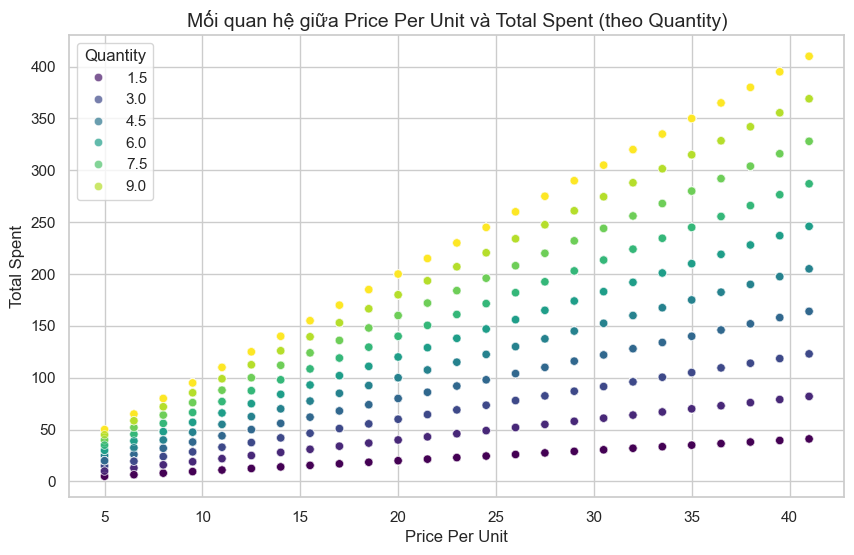

In [8]:
# 1. Mối quan hệ giữa Price Per Unit và Total Spent (Số vs Số)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Price Per Unit', y='Total Spent', hue='Quantity', palette='viridis', alpha=0.7)
plt.title('Mối quan hệ giữa Price Per Unit và Total Spent (theo Quantity)', fontsize=14)
plt.xlabel('Price Per Unit')
plt.ylabel('Total Spent')
plt.legend(title='Quantity')
plt.show()

### Mối quan hệ giữa các cột Phân loại và biến mục tiêu (Quantity)

C:\Users\Win 11\AppData\Local\Temp\ipykernel_5996\2152239392.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Location', y='Quantity', ax=axes[0], palette='pastel')
C:\Users\Win 11\AppData\Local\Temp\ipykernel_5996\2152239392.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Payment Method', y='Quantity', ax=axes[1], palette='pastel')


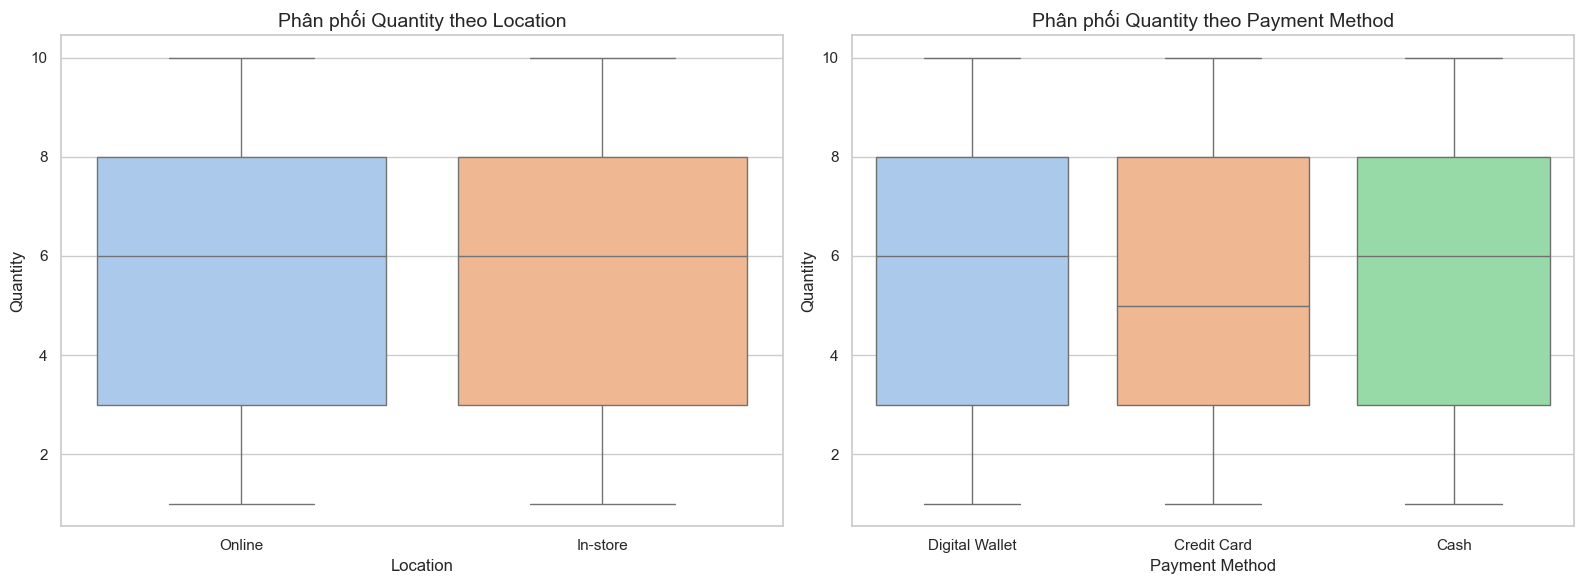

In [9]:
# 2. Phân phối Quantity theo Location và Payment Method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Location', y='Quantity', ax=axes[0], palette='pastel')
axes[0].set_title('Phân phối Quantity theo Location', fontsize=14)

sns.boxplot(data=df, x='Payment Method', y='Quantity', ax=axes[1], palette='pastel')
axes[1].set_title('Phân phối Quantity theo Payment Method', fontsize=14)

plt.tight_layout()
plt.show()

### Phân phối Quantity và Total Spent theo Category

C:\Users\Win 11\AppData\Local\Temp\ipykernel_5996\3547004256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Quantity', ax=axes[0], palette='Set2')
C:\Users\Win 11\AppData\Local\Temp\ipykernel_5996\3547004256.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Total Spent', ax=axes[1], palette='Set2')


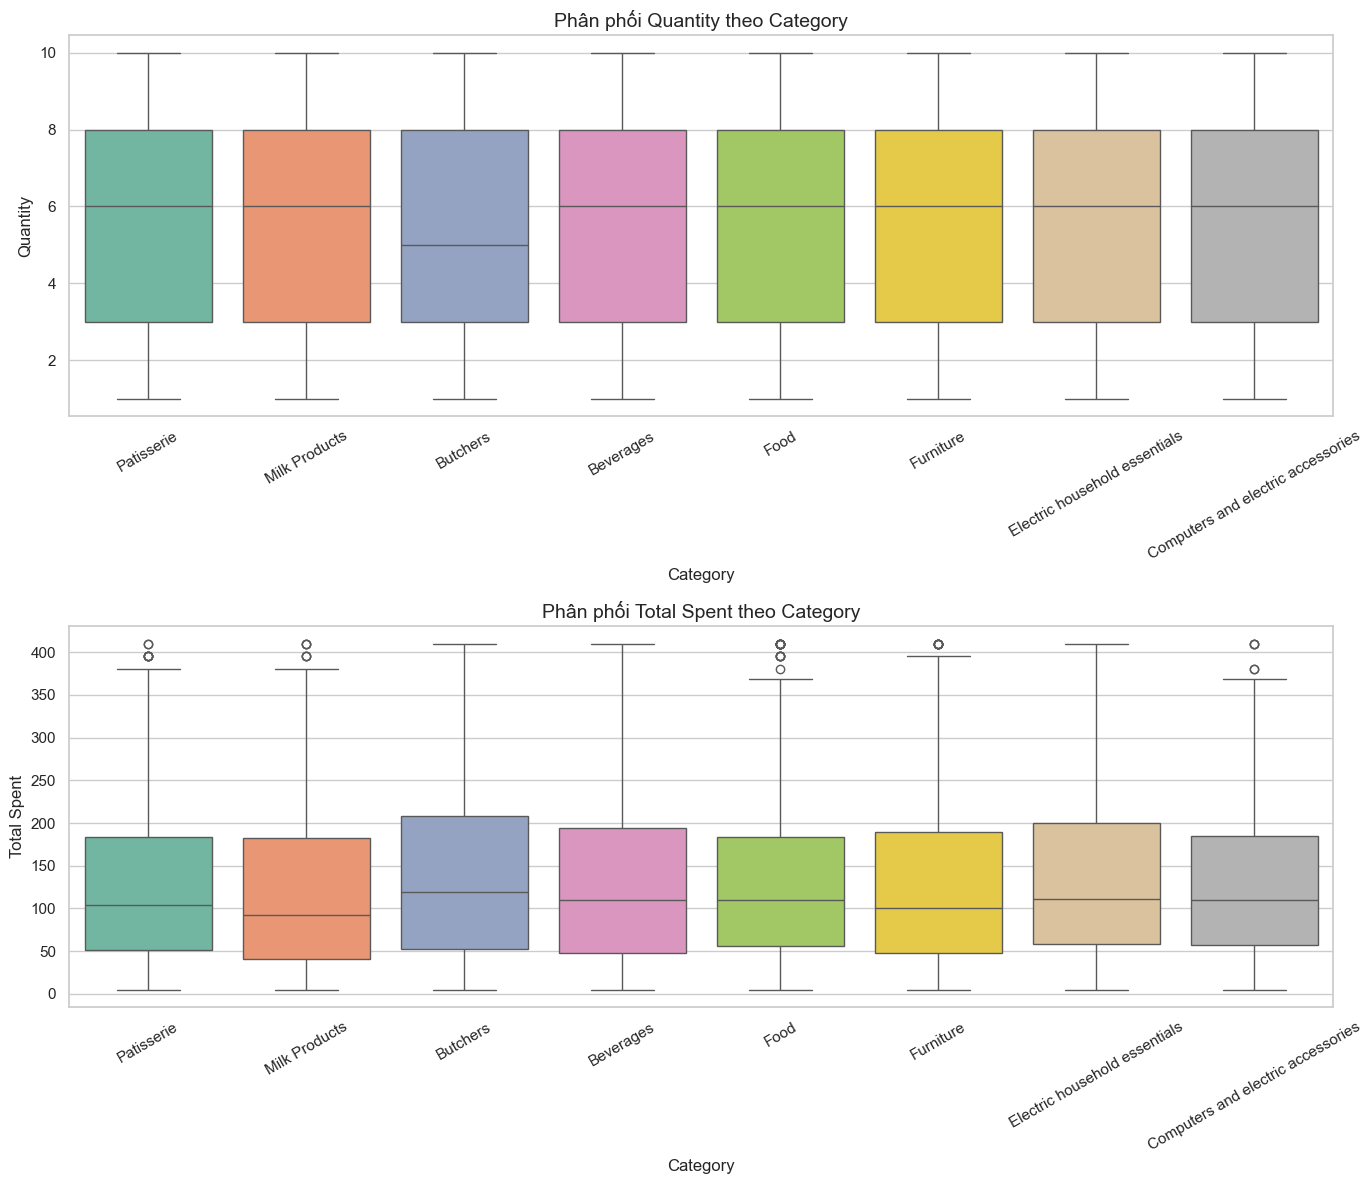

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.boxplot(data=df, x='Category', y='Quantity', ax=axes[0], palette='Set2')
axes[0].set_title('Phân phối Quantity theo Category', fontsize=14)
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Category', y='Total Spent', ax=axes[1], palette='Set2')
axes[1].set_title('Phân phối Total Spent theo Category', fontsize=14)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Ma trận tương quan (Correlation Matrix) giữa các cột số

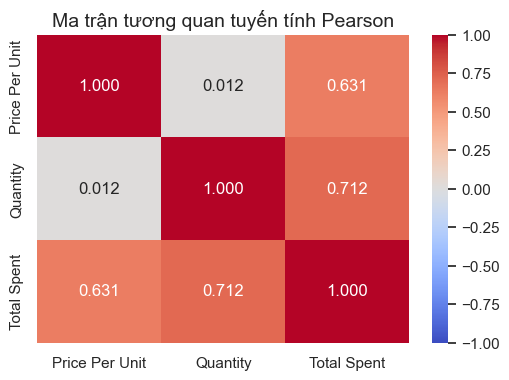

In [11]:
corr_matrix = df[['Price Per Unit', 'Quantity', 'Total Spent']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1)
plt.title('Ma trận tương quan tuyến tính Pearson', fontsize=14)
plt.show()

### Đánh giá đa cộng tuyến bằng chỉ số VIF (Variance Inflation Factor)

Chỉ số VIF giúp đo lường mức độ đa cộng tuyến giữa các biến số liên tục. Nếu $\text{VIF} \ge 5$, các biến có biểu hiện cộng tuyến mạnh.

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Loại bỏ giá trị thiếu để tính toán VIF
vif_data = df[['Price Per Unit', 'Quantity', 'Total Spent']].dropna()

# Thêm hằng số const làm hệ số chặn (intercept) theo yêu cầu của statsmodels
X_vif = add_constant(vif_data)

vif_df = pd.DataFrame()
vif_df["Đặc trưng (Feature)"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Loại bỏ dòng hằng số const khi hiển thị
vif_df = vif_df[vif_df["Đặc trưng (Feature)"] != 'const'].reset_index(drop=True)
print("=== CHỈ SỐ VIF GIỮA 3 BIẾN SỐ LIÊN TỤC ===")
display(vif_df)

=== CHỈ SỐ VIF GIỮA 3 BIẾN SỐ LIÊN TỤC ===


,Đặc trưng (Feature),VIF
0,Price Per Unit,4.709481
1,Quantity,5.761548
2,Total Spent,9.569940


# Bước 5. Nhận Diện Dữ Liệu Thiếu, Trùng Lặp & Ngoại Lệ (Missing Data, Duplicate Data & Outliers)

Kiểm tra chất lượng dữ liệu để phát hiện các dòng trùng lặp, tỷ lệ khuyết thiếu và tìm các điểm dữ liệu ngoại lệ bằng IQR.

In [13]:
# 1. Kiểm tra dữ liệu trùng lặp
dup_count = df.duplicated().sum()
txn_dup_count = df['Transaction ID'].duplicated().sum()
print(f'Số lượng bản ghi trùng lặp hoàn toàn: {dup_count}')
print(f'Số lượng Transaction ID bị trùng lặp: {txn_dup_count}')
print('-'*50)

# 2. Kiểm tra tỷ lệ dữ liệu thiếu ở mỗi thuộc tính
missing_sum = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({'Số ô trống': missing_sum, 'Tỷ lệ thiếu (%)': missing_pct})
print('--- Thống kê dữ liệu khuyết thiếu ---')
display(missing_summary)

Số lượng bản ghi trùng lặp hoàn toàn: 0
Số lượng Transaction ID bị trùng lặp: 0
--------------------------------------------------
--- Thống kê dữ liệu khuyết thiếu ---


,Số ô trống,Tỷ lệ thiếu (%)
Transaction ID,0,0.000000
Customer ID,0,0.000000
Category,0,0.000000
Item,1213,9.646123
Price Per Unit,609,4.842942
Quantity,604,4.803181
Total Spent,604,4.803181
Payment Method,0,0.000000
Location,0,0.000000
Transaction Date,0,0.000000


### Nhận diện ngoại lệ (Outliers) bằng phương pháp khoảng IQR

In [14]:
num_cols = ['Price Per Unit', 'Quantity', 'Total Spent']
outliers_summary = {}

for col in num_cols:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    outliers_summary[col] = {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Biên dưới': lower_bound, 'Biên trên': upper_bound,
        'Số lượng ngoại lệ': len(outliers),
        'Tỷ lệ ngoại lệ (%)': (len(outliers) / len(df)) * 100
    }

display(pd.DataFrame(outliers_summary).T)

,Q1,Q3,IQR,Biên dưới,Biên trên,Số lượng ngoại lệ,Tỷ lệ ngoại lệ (%)
Price Per Unit,14.0,33.5,19.5,-15.25,62.75,0.0,0.000000
Quantity,3.0,8.0,5.0,-4.50,15.50,0.0,0.000000
Total Spent,51.0,192.0,141.0,-160.50,403.50,60.0,0.477137


# Bước 6. Đánh Giá Chất Lượng Dữ Liệu & Trực Quan Hóa (Data Quality & Data Visualization)

### Tổng kết kết quả phân tích khám phá dữ liệu (EDA):
1. **Kích thước dữ liệu**: Bộ dữ liệu chứa 12,575 hàng và 11 cột thuộc tính.
2. **Phân phối biến mục tiêu `Quantity`**: Chạy từ 1 đến 10 với số lượng phân bố rất đồng đều ở mỗi mức giá trị (gần như phân phối phẳng/đều), không có outliers. Trung vị là 6.0 và Trung bình là 5.54.
3. **Hiện trạng dữ liệu lỗi & khuyết thiếu**:
    * `Price Per Unit` bị thiếu **609 dòng**, tuy nhiên các dòng này đều có đầy đủ `Quantity` và `Total Spent`. Có thể khôi phục bằng công thức: `Price Per Unit = Total Spent / Quantity`.
    * `Item` bị thiếu **1,213 dòng**. Từ phân tích cho thấy giá của mỗi sản phẩm là cố định và duy nhất trong danh mục của nó. Do đó, có thể khôi phục tên sản phẩm bị thiếu bằng bản đồ liên kết `(Category, Price Per Unit) -> Item`.
    * `Quantity` và `Total Spent` cùng thiếu **604 dòng** (co-missing). Do không thể khôi phục trực tiếp, chúng ta sẽ điền khuyết bằng giá trị trung bình (Mean) của cột tương ứng theo yêu cầu.
    * `Discount Applied` khuyết **4,199 dòng** (~33.4%). Sẽ được điền khuyết bằng giá trị `False` (giả định không có chiết khấu nếu không ghi nhận).
4. **Outliers**: Theo tính toán IQR, chỉ có cột `Total Spent` chứa 60 điểm bị coi là outlier (các giao dịch có giá trị trên 403.5 USD). Tuy nhiên, đây là kết quả của việc nhân giá lớn nhất (41.0) với số lượng lớn nhất (10) nên đây không phải là dữ liệu lỗi vật lý mà là dữ liệu hợp lệ. Do đó, chúng ta giữ nguyên các giá trị này.

### Đề xuất cho bước Feature Engineering kế tiếp:
- Thực hiện chia tách dữ liệu Train/Test trước khi điền khuyết để chống rò rỉ dữ liệu.
- Áp dụng các phương pháp khôi phục dữ liệu tùy chỉnh như đã phân tích.
- Tạo thêm các đặc trưng thời gian từ cột `Transaction Date`.
- Tạo thêm đặc trưng tích lũy từ lịch sử khách hàng `Customer ID`.
- Thực hiện One-Hot Encoding và Scaling dữ liệu số.

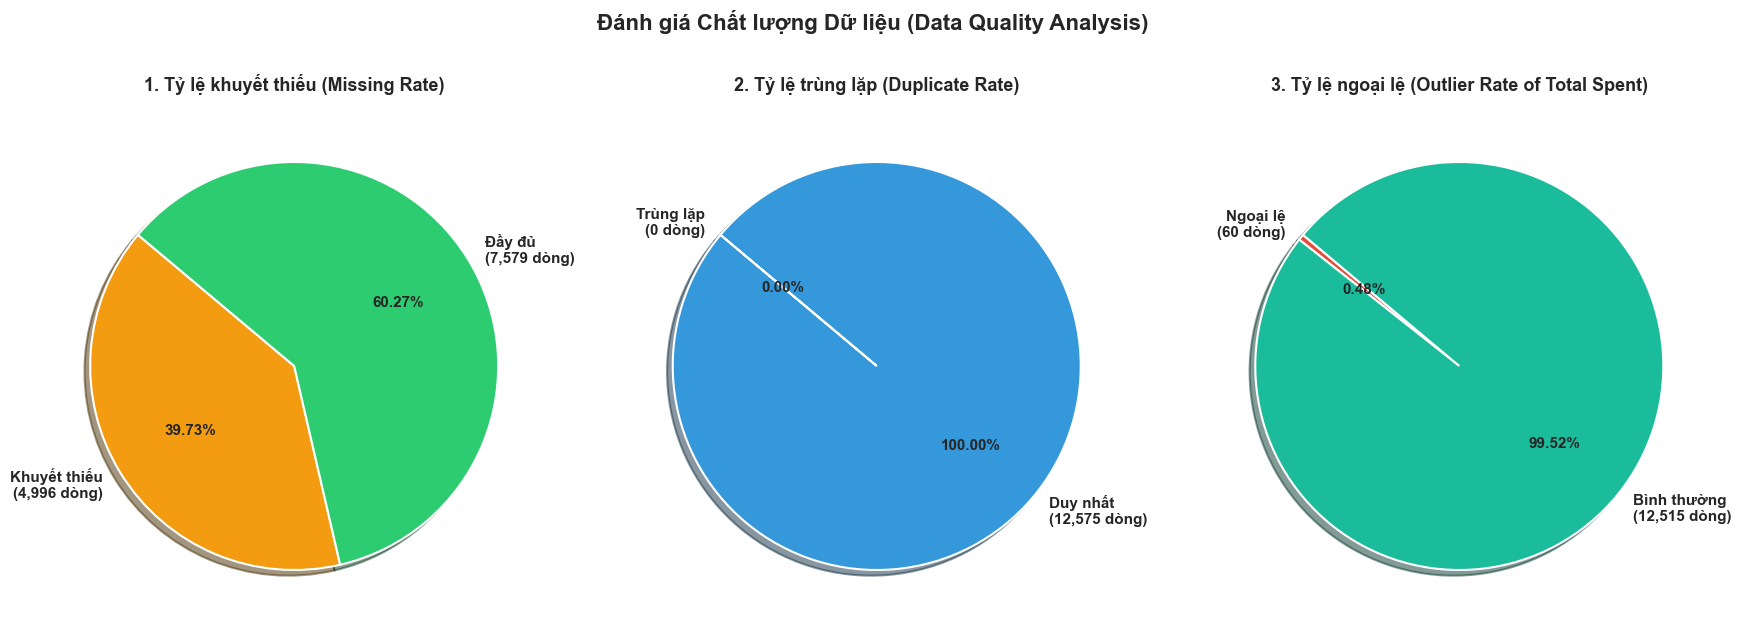

Tổng số dòng: 12,575
- Khuyết thiếu ít nhất 1 ô: 4,996 (39.73%) | Đầy đủ: 7,579 (60.27%)
- Trùng lặp hoàn toàn: 0 (0.00%) | Duy nhất: 12,575 (100.00%)
- Ngoại lệ (cột Total Spent): 60 (0.48%) | Bình thường: 12,515 (99.52%)


In [ ]:
# 1. Tính toán số liệu chất lượng dữ liệu
total_rows = len(df)

# A. Thiếu dữ liệu (Missing)
n_missing = df.isnull().any(axis=1).sum()
n_complete = total_rows - n_missing

# B. Trùng lặp (Duplicate)
n_dup = df.duplicated().sum()
n_unique = total_rows - n_dup

# C. Ngoại lệ (Outliers) cho Total Spent
q1 = df['Total Spent'].quantile(0.25)
q3 = df['Total Spent'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers_mask = (df['Total Spent'] > upper_bound) | (df['Total Spent'] < lower_bound)
n_outliers = df[outliers_mask].shape[0]
n_normal = total_rows - n_outliers

# Vẽ 3 biểu đồ tròn cạnh nhau (3 charts for 3 things)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Biểu đồ 1: Khuyết thiếu (Missing Data Ratio)
axes[0].pie(
    [n_missing, n_complete],
    labels=['Khuyết thiếu\n({:,} dòng)'.format(n_missing), 'Đầy đủ\n({:,} dòng)'.format(n_complete)],
    colors=['#f39c12', '#2ecc71'],
    autopct='%1.2f%%',
    shadow=True,
    startangle=140,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('1. Tỷ lệ khuyết thiếu (Missing Rate)', fontsize=13, fontweight='bold', pad=15)

# Biểu đồ 2: Trùng lặp (Duplicate Data Ratio)
axes[1].pie(
    [n_dup, n_unique],
    labels=['Trùng lặp\n({:,} dòng)'.format(n_dup), 'Duy nhất\n({:,} dòng)'.format(n_unique)],
    colors=['#9b59b6', '#3498db'],
    autopct='%1.2f%%',
    shadow=True,
    startangle=140,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('2. Tỷ lệ trùng lặp (Duplicate Rate)', fontsize=13, fontweight='bold', pad=15)

# Biểu đồ 3: Ngoại lệ (Outlier Ratio of Total Spent)
axes[2].pie(
    [n_outliers, n_normal],
    labels=['Ngoại lệ\n({:,} dòng)'.format(n_outliers), 'Bình thường\n({:,} dòng)'.format(n_normal)],
    colors=['#e74c3c', '#1abc9c'],
    autopct='%1.2f%%',
    shadow=True,
    startangle=140,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[2].set_title('3. Tỷ lệ ngoại lệ (Outlier Rate of Total Spent)', fontsize=13, fontweight='bold', pad=15)

plt.suptitle('Đánh giá Chất lượng Dữ liệu (Data Quality Analysis)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print(f"Tổng số dòng: {total_rows:,}")
print(f"- Khuyết thiếu ít nhất 1 ô: {n_missing:,} ({n_missing/total_rows*100:.2f}%) | Đầy đủ: {n_complete:,} ({n_complete/total_rows*100:.2f}%)")
print(f"- Trùng lặp hoàn toàn: {n_dup:,} ({n_dup/total_rows*100:.2f}%) | Duy nhất: {n_unique:,} ({n_unique/total_rows*100:.2f}%)")
print(f"- Ngoại lệ (cột Total Spent): {n_outliers:,} ({n_outliers/total_rows*100:.2f}%) | Bình thường: {n_normal:,} ({n_normal/total_rows*100:.2f}%)")